In [22]:
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import numpy as np

from matplotlib import pyplot as plt
from matplotlib.lines import Line2D

import seaborn as sns

from matplotlib_venn import venn3

import statsmodels.api as sm

import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

import descri_function as des_fun

from matplotlib.patches import Patch

In [2]:
from pathlib import Path

out_dir = Path('/home/juliane.oliveira/workspace/Data/sint_out_timing_per'
   # "/opt/storage/shared/aesop/aesop_shared/ensamble_modelling/sint_out_timing_per"
)

perf_files = sorted(out_dir.glob("performance_rep_*.parquet"))

timing_files = sorted(out_dir.glob("timing_rep_*.parquet"))

final_perf = pd.concat(
    [pd.read_parquet(f) for f in perf_files],
    ignore_index=True
)

final_timing = pd.concat(
    [pd.read_parquet(f) for f in timing_files],
    ignore_index=True
)

In [3]:
timing_files

[PosixPath('/home/juliane.oliveira/workspace/Data/sint_out_timing_per/timing_rep_0.parquet'),
 PosixPath('/home/juliane.oliveira/workspace/Data/sint_out_timing_per/timing_rep_1.parquet'),
 PosixPath('/home/juliane.oliveira/workspace/Data/sint_out_timing_per/timing_rep_10.parquet'),
 PosixPath('/home/juliane.oliveira/workspace/Data/sint_out_timing_per/timing_rep_11.parquet'),
 PosixPath('/home/juliane.oliveira/workspace/Data/sint_out_timing_per/timing_rep_12.parquet'),
 PosixPath('/home/juliane.oliveira/workspace/Data/sint_out_timing_per/timing_rep_13.parquet'),
 PosixPath('/home/juliane.oliveira/workspace/Data/sint_out_timing_per/timing_rep_14.parquet'),
 PosixPath('/home/juliane.oliveira/workspace/Data/sint_out_timing_per/timing_rep_15.parquet'),
 PosixPath('/home/juliane.oliveira/workspace/Data/sint_out_timing_per/timing_rep_16.parquet'),
 PosixPath('/home/juliane.oliveira/workspace/Data/sint_out_timing_per/timing_rep_17.parquet'),
 PosixPath('/home/juliane.oliveira/workspace/Data/si

# Format data

In [4]:
final_timing.model.unique()

array(['C2_alarms_0', 'sinal_evi_replicate_0', 'EWS_ISF_replicate_0',
       'EWS_LOF_replicate_0', 'EWS_OCSVM_replicate_0',
       'EWS_COPOD_replicate_0', 'EWS_Rt_replicate_0',
       'hard_voting_ivas_rep_0', 'sinal_ens_ivas_rep_0',
       'signal_ensemble_xgb50_rep_0', 'signal_ensemble_mlp50_rep_0',
       'C2_alarms_1', 'sinal_evi_replicate_1', 'EWS_ISF_replicate_1',
       'EWS_LOF_replicate_1', 'EWS_OCSVM_replicate_1',
       'EWS_COPOD_replicate_1', 'EWS_Rt_replicate_1',
       'hard_voting_ivas_rep_1', 'sinal_ens_ivas_rep_1',
       'signal_ensemble_xgb50_rep_1', 'signal_ensemble_mlp50_rep_1',
       'C2_alarms_10', 'sinal_evi_replicate_10', 'EWS_ISF_replicate_10',
       'EWS_LOF_replicate_10', 'EWS_OCSVM_replicate_10',
       'EWS_COPOD_replicate_10', 'EWS_Rt_replicate_10',
       'hard_voting_ivas_rep_10', 'sinal_ens_ivas_rep_10',
       'signal_ensemble_xgb50_rep_10', 'signal_ensemble_mlp50_rep_10',
       'C2_alarms_11', 'sinal_evi_replicate_11', 'EWS_ISF_replicate_11',
 

In [5]:
final_timing['model'] = (
    final_timing['model']
    .str.replace(r'^C2_alarms_\d+$', 'EARS', regex=True)
    .str.replace(r'^sinal_evi_replicate_\d+$', 'EVI', regex=True)
    .str.replace(r'^EWS_OCSVM_replicate_\d+$', 'OCSVM', regex=True)
    .str.replace(r'^EWS_Rt_replicate_\d+$', 'NGM', regex=True)
    .str.replace(r'^EWS_LOF_replicate_\d+$', 'LOF', regex=True)
    .str.replace(r'^EWS_ISF_replicate_\d+$',   'ISF', regex=True)
    .str.replace(r'^hard_voting_ivas_rep_\d+$','MV', regex=True)
    .str.replace(r'^EWS_COPOD_replicate_\d+$', 'COPOD', regex=True)
    .str.replace(r'^sinal_ens_ivas_rep_\d+$',  'LR', regex=True)
    .str.replace(r'^signal_ensemble_xgb50_rep_\d+$', 'XGB', regex=True)
    .str.replace(r'^signal_ensemble_mlp50_rep_\d+$', 'MLP', regex=True)
)

In [6]:
final_timing['intensity_level'] = (
    final_timing['intensity_level'] 
    .str.replace(r'^mem_low_rep_\d+$', 'Low', regex=True)
    .str.replace(r'^mem_sub_rep_\d+$', 'Sub-threshold', regex=True)
    .str.replace(r'^mem_medium_rep_\d+$', 'Medium', regex=True)
    .str.replace(r'^mem_high_rep_\d+$', 'High', regex=True)
    .str.replace(r'^mem_very_high_rep_\d+$', 'Very High', regex=True)
)


In [7]:
final_timing.intensity_level.unique()

array(['Sub-threshold', 'Low', 'Medium', 'High', 'Very High'],
      dtype=object)

In [56]:
dta = final_timing.groupby(['model', 'intensity_level', 'rep'])[['n3', 'n2', 'n1', 'n0', 'missed', 'total_aih_warning']].sum().reset_index()

In [57]:
dta = dta.assign(n3_per = dta.n3*100/dta.total_aih_warning,
                 n2_per = dta.n2*100/dta.total_aih_warning,
                 n1_per = dta.n1*100/dta.total_aih_warning,
                 n0_per = dta.n0*100/dta.total_aih_warning,
                 missed_per = dta.missed*100/dta.total_aih_warning)

In [58]:
def add_ci(df, col_num, col_model):

    mean_list = []
    lower_list = []
    upper_list = []

    for model in df[col_model]:

        dta = df[df[col_model] == model]

        m, l, u = des_fun.mean_confidence_interval2(
            dta[col_num]
        )

        mean_list.append(m)
        lower_list.append(l)
        upper_list.append(u)

    df[f"{col_num.replace('_per', '')}_CI_mean"] = mean_list
    df[f"{col_num.replace('_per', '')}_CI_low"] = lower_list
    df[f"{col_num.replace('_per', '')}_CI_high"] = upper_list

    return df

In [59]:
cols_to_ci = ['n3_per', 'n2_per', 'n1_per', 'n0_per','missed_per']

lst = []

for int in dta.intensity_level.unique():

    dta_int = dta[dta.intensity_level == int]
    
    for col in cols_to_ci:
        add_ci(dta_int, col, 'model' )

    lst.append(dta_int)

/tmp/ipykernel_3686421/66177463.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f"{col_num.replace('_per', '')}_CI_mean"] = mean_list
/tmp/ipykernel_3686421/66177463.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f"{col_num.replace('_per', '')}_CI_low"] = lower_list
/tmp/ipykernel_3686421/66177463.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: ht

In [60]:
res = pd.concat(lst)

In [66]:
res[res.model == 'LR'][['model', 'intensity_level','n3_CI_mean',  'n2_CI_mean',
        'n1_CI_mean', 
       'n0_CI_mean',  'missed_CI_mean']]

,model,intensity_level,n3_CI_mean,n2_CI_mean,n1_CI_mean,n0_CI_mean,missed_CI_mean
450,LR,High,29.6814,15.1192,11.9025,26.5693,16.7277
451,LR,High,29.6814,15.1192,11.9025,26.5693,16.7277
452,LR,High,29.6814,15.1192,11.9025,26.5693,16.7277
453,LR,High,29.6814,15.1192,11.9025,26.5693,16.7277
454,LR,High,29.6814,15.1192,11.9025,26.5693,16.7277
...,...,...,...,...,...,...,...
535,LR,Very High,33.5152,17.1367,12.8717,22.5131,13.9633
536,LR,Very High,33.5152,17.1367,12.8717,22.5131,13.9633
537,LR,Very High,33.5152,17.1367,12.8717,22.5131,13.9633
538,LR,Very High,33.5152,17.1367,12.8717,22.5131,13.9633


In [67]:
res = res.groupby(['model', 'intensity_level'])[[
       'n3_CI_mean', 'n3_CI_low', 'n3_CI_high', 'n2_CI_mean', 'n2_CI_low',
       'n2_CI_high', 'n1_CI_mean', 'n1_CI_low', 'n1_CI_high', 'n0_CI_mean',
       'n0_CI_low', 'n0_CI_high', 'missed_CI_mean', 'missed_CI_low',
       'missed_CI_high']].max().reset_index()

In [70]:
res[res.model == 'LR'][['model', 'intensity_level','n3_CI_mean',  'n2_CI_mean',
        'n1_CI_mean', 
       'n0_CI_mean',  'missed_CI_mean']]

,model,intensity_level,n3_CI_mean,n2_CI_mean,n1_CI_mean,n0_CI_mean,missed_CI_mean
25,LR,High,29.6814,15.1192,11.9025,26.5693,16.7277
26,LR,Low,17.8252,10.7299,10.0415,37.3672,24.0362
27,LR,Medium,22.8845,13.1030,10.3220,31.9086,21.7818
28,LR,Sub-threshold,6.2643,4.4601,4.2882,47.3728,37.6146
29,LR,Very High,33.5152,17.1367,12.8717,22.5131,13.9633


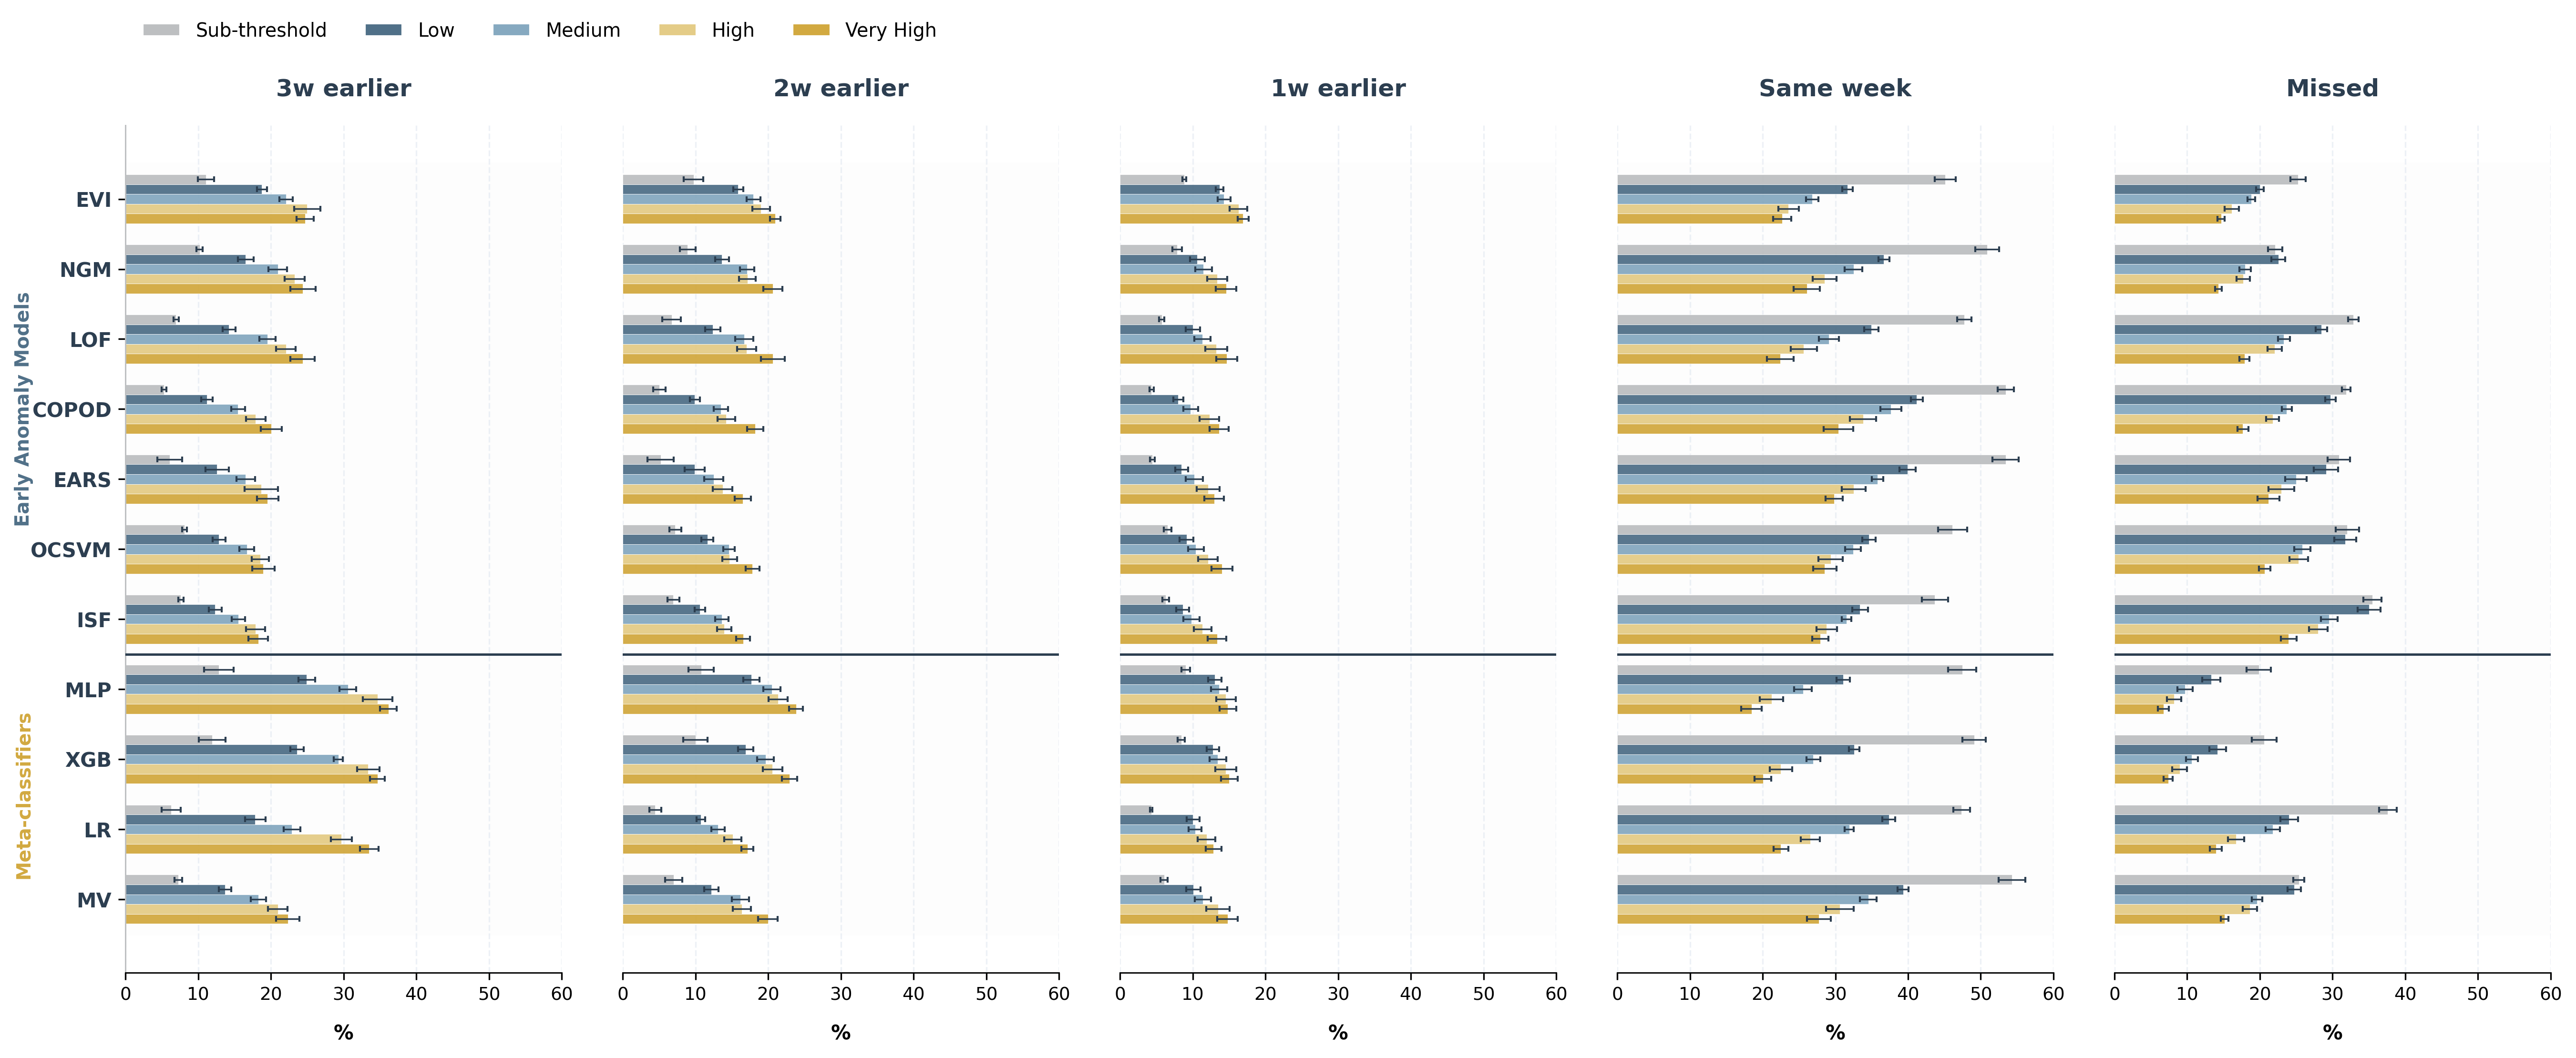

In [76]:
df_base = res

# --- 2. Structural Architecture Sorting ---
group_mapping = {
    'COPOD': 'Early Anomaly Models', 'EARS': 'Early Anomaly Models', 
    'EVI': 'Early Anomaly Models', 'ISF': 'Early Anomaly Models', 
    'LOF': 'Early Anomaly Models', 'NGM': 'Early Anomaly Models', 
    'OCSVM': 'Early Anomaly Models', 'LR': 'Meta-classifiers', 
    'MLP': 'Meta-classifiers', 'MV': 'Meta-classifiers', 'XGB': 'Meta-classifiers'
}
df_base['Group'] = df_base['model'].map(group_mapping)

df_sort_anchor = df_base[df_base['intensity_level'] == 'Very High'].copy()
df_sort_anchor = df_sort_anchor.sort_values(by=['Group', 'n3_CI_mean'], ascending=[True, False])
sorted_models = df_sort_anchor['model'].tolist()

intensity_order = ['Sub-threshold', 'Low', 'Medium', 'High', 'Very High']
timing_metrics = ['n3', 'n2', 'n1', 'n0', 'missed']
column_headers = ['3w earlier', '2w earlier', '1w earlier', 'Same week', 'Missed']

# Elegant Slate-to-Gold Color System
palette = {
    'Sub-threshold': '#bdbfc1',
    'Low': '#507088',
    'Medium': '#86a9c0',
    'High': '#e4cc87',
    'Very High': '#d2a940'
}
GREY_SPINE = '#bdbfc1'

# --- 3. Positional Math for Grouped Bar Dodging ---
base_spacing = 1.0       # Spacing between different models
bar_height = 0.14        # Thickness of individual intensity bars
# Center the group of bars over the model anchor point
center_offset = (len(intensity_order) - 1) * bar_height / 2

model_anchors = np.arange(len(sorted_models)) * base_spacing
split_idx = next(idx for idx, m in enumerate(sorted_models) if group_mapping[m] == 'Meta-classifiers')
line_y = (model_anchors[split_idx-1] + model_anchors[split_idx]) / 2

# --- 4. Plot Initialization ---
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'Liberation Sans', 'DejaVu Sans'],
    'pdf.fonttype': 42,
    'axes.linewidth': 0.7,
    'xtick.labelsize': 9,
    'ytick.labelsize': 10
})

# Single row of plots: 1 Row x 5 Columns
fig, axes = plt.subplots(1, 5, figsize=(18, 8), sharey=True, dpi=300)

# --- 5. Plotting Engine ---
for col_idx, metric in enumerate(timing_metrics):
    ax = axes[col_idx]
    
    # Render clean background alternative horizontal lane guides
    for anchor in model_anchors:
        ax.axhspan(anchor - base_spacing/2, anchor + base_spacing/2, color='#fdfdfd', alpha=0.5, zorder=0)
        
    # Plot intensity blocks as solid bar tracks layered sequentially
    for intensity_idx, level in enumerate(intensity_order):
        df_sub = df_base[(df_base['intensity_level'] == level)].set_index('model').reindex(sorted_models).reset_index()
        
        # Shift the vertical placement of each bar to cluster them together
        y_positions = model_anchors - center_offset + (intensity_idx * bar_height)
        
        means = df_sub[f'{metric}_CI_mean']
        lows = df_sub[f'{metric}_CI_low']
        highs = df_sub[f'{metric}_CI_high']
        x_err = [means - lows, highs - means]
        
        # Draw the anchored performance bars
        ax.barh(
            y_positions, means, height=bar_height, color=palette[level], 
            edgecolor='white', linewidth=0.2, alpha=0.95, zorder=2
        )
        
        # Overlay the error bars directly on top of the bars
        ax.errorbar(
            means, y_positions, xerr=x_err, fmt='none', ecolor='#2c3e50',
            capsize=1.5, elinewidth=0.8, zorder=3
        )

    # Architectural group break line
    ax.axhline(y=line_y, color='#2C3E50', linewidth=1.2, linestyle='-', zorder=4)
    
    ax.set_title(column_headers[col_idx], fontsize=12, fontweight='bold', pad=15, color='#2C3E50')
    ax.set_xlabel('%', fontsize=10, fontweight='bold', labelpad=10)
    ax.set_xlim(0, 60)
    ax.xaxis.grid(True, linestyle='--', color='#e2e8f0', alpha=0.6, zorder=1)
    ax.set_axisbelow(True)
    
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    if col_idx > 0:
        ax.spines['left'].set_visible(False)
        ax.tick_params(left=False)

# --- 6. Global Formatting & Group Margins ---
# Anchor the model labels precisely to the center of each bar group
axes[0].set_yticks(model_anchors)
axes[0].set_yticklabels(sorted_models, fontsize=10, fontweight='bold', color='#2C3E50')
axes[0].invert_yaxis()
axes[0].spines['left'].set_color(GREY_SPINE)

# Structural block labels on the far left margin
axes[0].text(-14, (model_anchors[split_idx-1] / 2), 'Early Anomaly Models', va='center', ha='center', fontsize=9.5, fontweight='bold', rotation=90, color='#507088')
axes[0].text(-14, (model_anchors[split_idx] + (model_anchors[-1] - model_anchors[split_idx])/2), 'Meta-classifiers', va='center', ha='center', fontsize=9.5, fontweight='bold', rotation=90, color='#d2a940')

# --- 7. Unified Horizontal Legend Placement ---
legend_elements = [Patch(facecolor=palette[lvl], edgecolor='white', label=lvl) for lvl in intensity_order]
axes[0].legend(
    handles=legend_elements,
    loc='lower left',
    bbox_to_anchor=(0.0, 1.08),
    ncol=5,
    frameon=False,
    fontsize=9.5
)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.subplots_adjust(wspace=0.14)

plt.savefig('/home/juliane.oliveira/workspace/aesop-detection-models/figures/timing_matrix_bars.png', bbox_inches='tight')
plt.show()